In [3]:
pip install wrds

Note: you may need to restart the kernel to use updated packages.


In [11]:
import wrds

def connect_wrds():
    db = wrds.Connection()
    return db

def get_columns(db):
    query = """
    select column_name
    from information_schema.columns
    where table_schema = 'comp' and table_name = 'funda'
    order by ordinal_position
    """
    cols = db.raw_sql(query)
    print(cols)

if __name__ == "__main__":
    db = connect_wrds()
    get_columns(db)

Enter your WRDS username [khy]: cky2116874052
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
    column_name
0         gvkey
1      datadate
2         fyear
3        indfmt
4        consol
..          ...
944          au
945        auop
946      auopic
947       ceoso
948       cfoso

[949 rows x 1 columns]


In [12]:
import wrds
import pandas as pd

def connect_wrds():
    db = wrds.Connection()
    return db

def get_financial_data(db, start='2018-01-01', end='2022-12-31'):
    query = f"""
    select gvkey, datadate, fyear, at, dltt, revt, ni, mkvalt
    from comp.funda
    where indfmt='INDL' and consol='C' and datafmt='STD' and popsrc='D'
    and datadate between '{start}' and '{end}'
    and at > 0 and revt > 0
    order by gvkey, datadate
    """
    df = db.raw_sql(query)
    df['datadate'] = pd.to_datetime(df['datadate'])
    df['year'] = df['datadate'].dt.year
    return df

def main():
    db = connect_wrds()
    df = get_financial_data(db)

    df = df.dropna(subset=['at', 'dltt', 'revt', 'ni'])
    df['debt_ratio'] = df['dltt'] / df['at']
    df['net_profit_margin'] = df['ni'] / df['revt']
    df['asset_turnover'] = df['revt'] / df['at']
    df['equity'] = df['at'] - df['dltt']
    df = df[df['equity'] > 0]
    df['roe'] = df['ni'] / df['equity']

    print(df.head())
    df.to_csv('financial_ratios_no_industry.csv', index=False)
    print("数据已保存到 financial_ratios_no_industry.csv")

if __name__ == '__main__':
    main()

Enter your WRDS username [khy]: cky2116874052
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
    gvkey   datadate  fyear      at   dltt    revt    ni     mkvalt  year  \
0  001004 2018-05-31   2017  1524.7  177.2  1748.3  15.6   1551.458  2018   
1  001004 2019-05-31   2018  1517.2  141.7  2051.8   7.5  1046.7709  2019   
2  001004 2020-05-31   2019  2079.0  670.9  2089.3   4.4   707.9065  2020   
3  001004 2021-05-31   2020  1539.7  193.6  1651.4  35.8  1476.9063  2021   
4  001004 2022-05-31   2021  1573.9  156.3  1817.1  78.7   1706.554  2022   

   debt_ratio  net_profit_margin  asset_turnover  equity       roe  
0     0.11622           0.008923        1.146652  1347.5  0.011577  
1    0.093396           0.003655         1.35236  1375.5  0.005453  
2    0.322703           0.002106        1.004954  1408.1  0.003125  
3    0.125739           0.021679        1.072547  1346.1  0.026595  
4    0.099307           0.043311        1.

   year  roe_mean     roe_std  debt_ratio_mean  debt_ratio_std  \
0  2018 -0.543046    8.206936         0.195015        0.211160   
1  2019 -0.422456    6.571473         0.216239        0.213231   
2  2020 -0.337375   14.472866         0.225521        0.216960   
3  2021 -0.345812    4.986149         0.210786        0.210284   
4  2022  1.214517  165.081193         0.214815        0.212963   

   net_profit_margin_mean  net_profit_margin_std  asset_turnover_mean  \
0               -9.386124             165.933502             0.751697   
1              -12.174808             211.273391             0.697807   
2              -18.191086             315.143853            76.906151   
3              -27.495764            1042.839378             0.601132   
4              -12.531676             202.314020             0.716307   

   asset_turnover_std  
0            1.910875  
1            1.193239  
2         6262.699552  
3            1.063475  
4            2.230838  


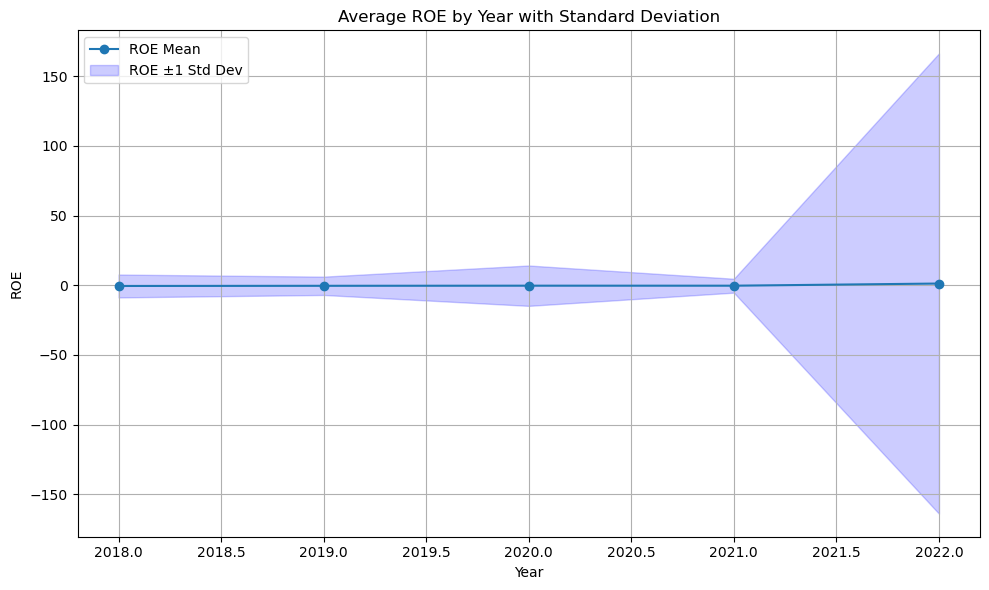

汇总数据已保存到 financial_ratios_summary_by_year.csv

2022年平均ROE为1.2145，标准差为165.0812。
你可以根据这个趋势图和数据，分析公司盈利能力的变化趋势。


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 读取之前保存的数据
df = pd.read_csv('financial_ratios_no_industry.csv')

# 2. 按年份计算指标均值和标准差
summary = df.groupby('year').agg({
    'roe': ['mean', 'std'],
    'debt_ratio': ['mean', 'std'],
    'net_profit_margin': ['mean', 'std'],
    'asset_turnover': ['mean', 'std']
}).reset_index()

# 改善列名，方便后续使用
summary.columns = ['year',
                   'roe_mean', 'roe_std',
                   'debt_ratio_mean', 'debt_ratio_std',
                   'net_profit_margin_mean', 'net_profit_margin_std',
                   'asset_turnover_mean', 'asset_turnover_std']

print(summary)

# 3. 绘制ROE随年份的变化趋势图
plt.figure(figsize=(10,6))
plt.plot(summary['year'], summary['roe_mean'], marker='o', linestyle='-', label='ROE Mean')
plt.fill_between(summary['year'],
                 summary['roe_mean'] - summary['roe_std'],
                 summary['roe_mean'] + summary['roe_std'],
                 color='b', alpha=0.2, label='ROE ±1 Std Dev')
plt.title('Average ROE by Year with Standard Deviation')
plt.xlabel('Year')
plt.ylabel('ROE')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 4. 保存汇总结果
summary.to_csv('financial_ratios_summary_by_year.csv', index=False)
print("汇总数据已保存到 financial_ratios_summary_by_year.csv")

# 5. 简单分析结论打印
latest_year = summary['year'].max()
latest_data = summary[summary['year'] == latest_year].iloc[0]
print(f"\n{latest_year}年平均ROE为{latest_data['roe_mean']:.4f}，标准差为{latest_data['roe_std']:.4f}。")
print("你可以根据这个趋势图和数据，分析公司盈利能力的变化趋势。")

In [14]:
corr = df[['roe', 'debt_ratio', 'net_profit_margin', 'asset_turnover']].corr()
print("指标相关性矩阵：\n", corr)

指标相关性矩阵：
                         roe  debt_ratio  net_profit_margin  asset_turnover
roe                1.000000   -0.012230           0.006984        0.072716
debt_ratio        -0.012230    1.000000           0.019279       -0.005423
net_profit_margin  0.006984    0.019279           1.000000        0.000177
asset_turnover     0.072716   -0.005423           0.000177        1.000000


In [15]:
import pandas as pd

# 读取数据
df = pd.read_csv('financial_ratios_no_industry.csv')

# 计算相关系数矩阵
corr = df[['roe', 'debt_ratio', 'net_profit_margin', 'asset_turnover']].corr()
print("财务指标相关性矩阵：")
print(corr)

财务指标相关性矩阵：
                        roe  debt_ratio  net_profit_margin  asset_turnover
roe                1.000000   -0.012230           0.006984        0.072716
debt_ratio        -0.012230    1.000000           0.019279       -0.005423
net_profit_margin  0.006984    0.019279           1.000000        0.000177
asset_turnover     0.072716   -0.005423           0.000177        1.000000


In [16]:
# 第二步：数据清洗（缺失值、异常值、筛选年份2018-2022）
import pandas as pd
import numpy as np

# 读取之前保存的财务数据（假设存在于可访问的公开路径或已加载变量 df）
# 这里示范从CSV读取，你可根据实际环境调整路径或数据加载方式
df = pd.read_csv('financial_ratios_no_industry.csv')

# 筛选2018-2022年数据
df = df[(df['year'] >= 2018) & (df['year'] <= 2022)]

# 检查关键指标缺失情况
key_cols = ['ni', 'revt', 'at', 'equity', 'dltt', 'mkvalt', 'roe']
print("关键指标缺失值统计：")
print(df[key_cols].isnull().sum())

# 删除缺失值较多的行（这里以ROE和基础变量缺失为准）
df_clean = df.dropna(subset=key_cols)

# 处理异常值：剔除ROE绝对值大于1（100%）的极端异常值
df_clean = df_clean[(df_clean['roe'] >= -1) & (df_clean['roe'] <= 1)]

# 简单打印清洗后数据概况
print(f"\n清洗后数据行数：{df_clean.shape[0]}")
print(df_clean[['year', 'roe']].describe())

关键指标缺失值统计：
ni           0
revt         0
at           0
equity       0
dltt         0
mkvalt    7134
roe          0
dtype: int64

清洗后数据行数：24924
               year           roe
count  24924.000000  24924.000000
mean    2020.009469     -0.037499
std        1.419251      0.235819
min     2018.000000     -0.999971
25%     2019.000000     -0.080640
50%     2020.000000      0.012408
75%     2021.000000      0.076132
max     2022.000000      0.995853


In [17]:
# 第三步：计算杜邦三因子（净利率、资产周转率、权益乘数）

# 净利率 = 净利润 / 营业收入
df_clean['net_profit_margin'] = df_clean['ni'] / df_clean['revt']

# 资产周转率 = 营业收入 / 总资产
df_clean['asset_turnover'] = df_clean['revt'] / df_clean['at']

# 权益乘数 = 总资产 / 股东权益
df_clean['equity_multiplier'] = df_clean['at'] / df_clean['equity']

# 检查计算结果的基本统计描述
print(df_clean[['net_profit_margin', 'asset_turnover', 'equity_multiplier']].describe())

# 计算杜邦分析ROE（理论值，验证准确性）
df_clean['roe_dupont'] = df_clean['net_profit_margin'] * df_clean['asset_turnover'] * df_clean['equity_multiplier']

# 比较计算ROE与财报ROE差异，检查是否一致
df_clean['roe_diff'] = df_clean['roe'] - df_clean['roe_dupont']
print("\nROE与杜邦分解计算值差异描述：")
print(df_clean['roe_diff'].describe())

       net_profit_margin  asset_turnover  equity_multiplier
count       24924.000000    24924.000000       24924.000000
mean           -7.482784        0.649552           1.444819
std           168.604291        0.777833           1.148894
min        -11618.333333        0.000039           1.000000
25%            -0.118351        0.125366           1.022602
50%             0.038162        0.458221           1.184369
75%             0.150942        0.915137           1.541840
max          2033.000000       35.195489          57.329077

ROE与杜邦分解计算值差异描述：
count    2.492400e+04
mean    -1.386242e-17
std      5.625561e-17
min     -4.440892e-16
25%     -5.551115e-17
50%     -1.387779e-17
75%      2.081668e-17
max      3.330669e-16
Name: roe_diff, dtype: float64


In [ ]:
/Users/khy/Desktop/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/khy/Desktop/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/khy/Desktop/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/khy/Desktop/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/khy/Desktop/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/khy/Desktop/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)

/Users/khy/Desktop/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/khy/Desktop/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/khy/Desktop/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/khy/Desktop/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/khy/Desktop/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/khy/Desktop/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36235 (\N{CJK UNIFIED IDEOGRAPH-8D8B}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/khy/Desktop/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/khy/Desktop/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20221 (\N{CJK UNIFIED IDEOGRAPH-4EFD}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


Click to add a cell.

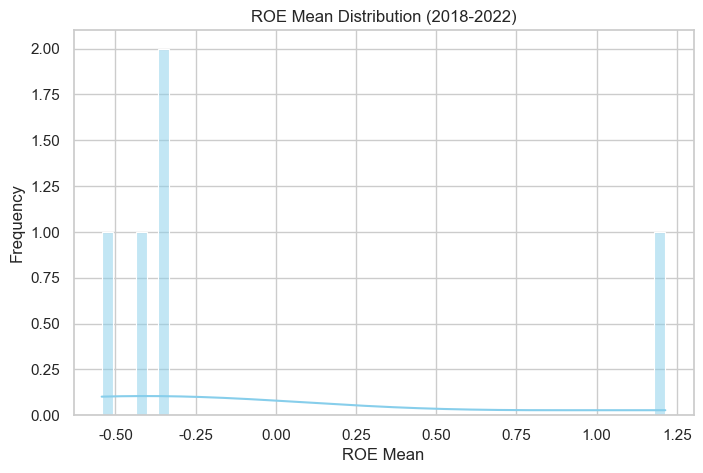

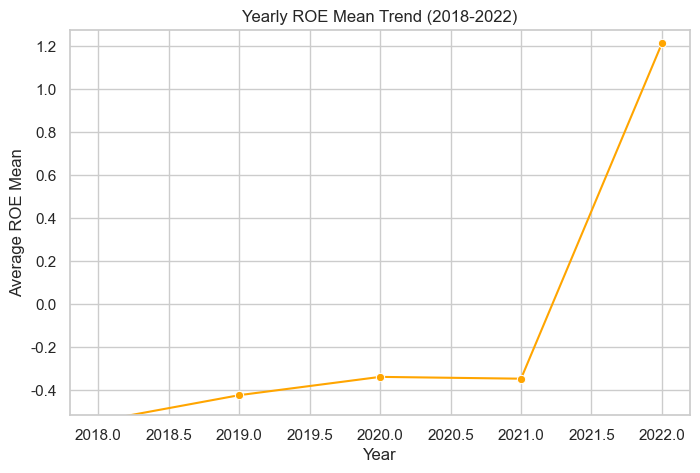

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# Set font to Arial (default English font) and properly display minus sign
matplotlib.rcParams['font.sans-serif'] = ['Arial']
matplotlib.rcParams['axes.unicode_minus'] = False

# Read data
df_raw = pd.read_csv('financial_ratios_summary_by_year.csv')
df_raw.columns = df_raw.columns.str.strip()

# Drop rows with missing 'roe_mean' or 'year'
df_clean = df_raw.dropna(subset=['roe_mean', 'year'])

sns.set(style="whitegrid")

# 1) Histogram of ROE Mean Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['roe_mean'], bins=50, kde=True, color='skyblue')
plt.title('ROE Mean Distribution (2018-2022)')
plt.xlabel('ROE Mean')
plt.ylabel('Frequency')
plt.show()

# 2) Line plot of yearly ROE Mean trend
roe_yearly = df_clean.groupby('year')['roe_mean'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(data=roe_yearly, x='year', y='roe_mean', marker='o', color='orange')
plt.title('Yearly ROE Mean Trend (2018-2022)')
plt.xlabel('Year')
plt.ylabel('Average ROE Mean')
plt.ylim(roe_yearly['roe_mean'].min() * 0.95, roe_yearly['roe_mean'].max() * 1.05)
plt.show()

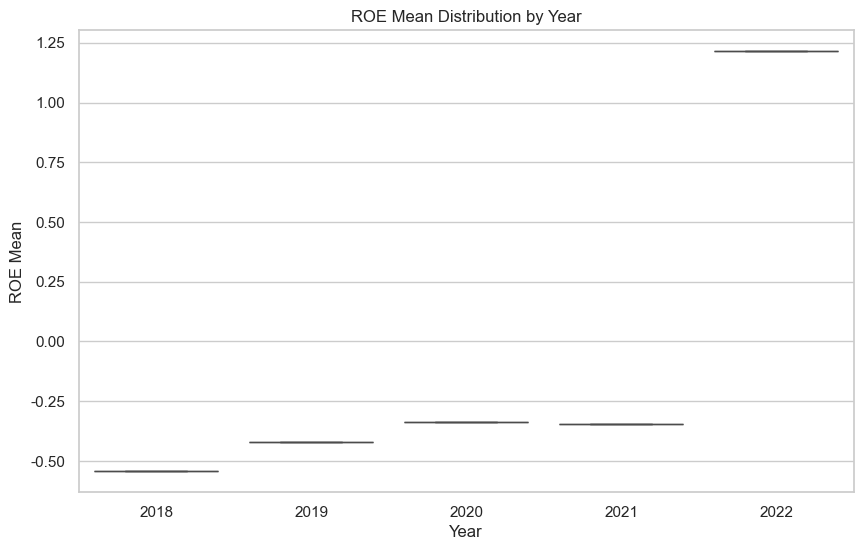

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='year', y='roe_mean')
plt.title('ROE Mean Distribution by Year')
plt.xlabel('Year')
plt.ylabel('ROE Mean')
plt.show()

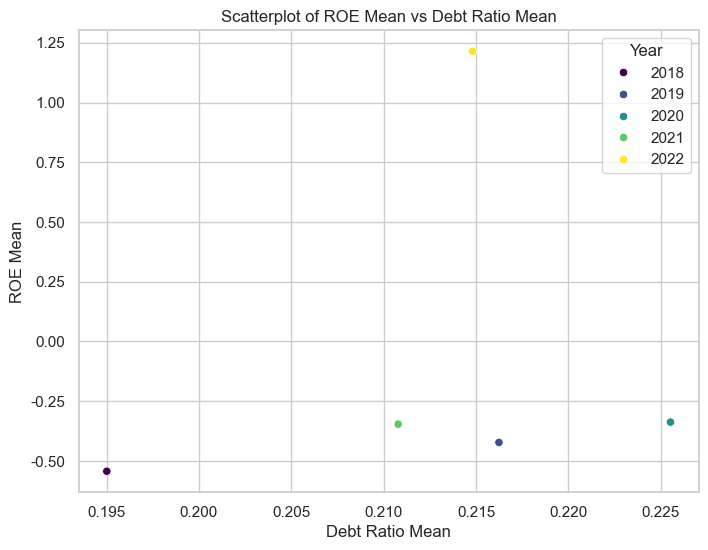

In [7]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_clean, x='debt_ratio_mean', y='roe_mean', hue='year', palette='viridis')
plt.title('Scatterplot of ROE Mean vs Debt Ratio Mean')
plt.xlabel('Debt Ratio Mean')
plt.ylabel('ROE Mean')
plt.legend(title='Year')
plt.show()

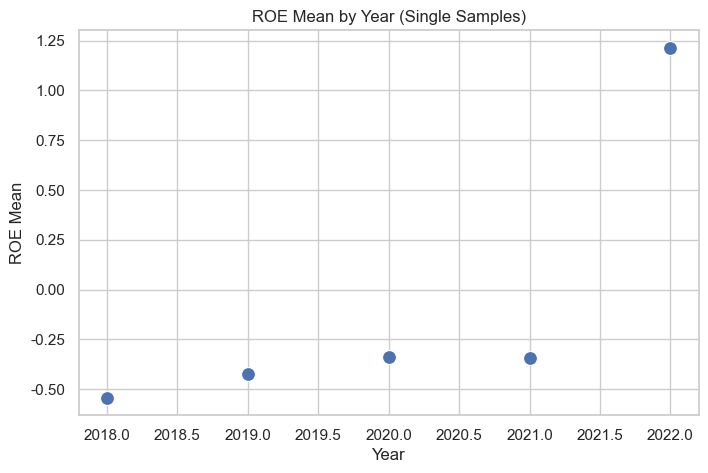

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x='year', y='roe_mean', s=100)
plt.title('ROE Mean by Year (Single Samples)')
plt.xlabel('Year')
plt.ylabel('ROE Mean')
plt.show()

In [11]:
df_clean['period'] = df_clean['year'].apply(lambda x: '2018-2020' if x <= 2020 else '2021-2022')

counts_period = df_clean.groupby('period').size()
print("各时间段样本数量：")
print(counts_period)

各时间段样本数量：
period
2018-2020    3
2021-2022    2
dtype: int64


各时间段ROE描述统计：
           count      mean       std       min       25%       50%       75%  \
period                                                                         
2018-2020    3.0 -0.434292  0.103345 -0.543046 -0.482751 -0.422456 -0.379915   
2021-2022    2.0  0.434353  1.103320 -0.345812  0.044270  0.434353  0.824435   

                max  
period               
2018-2020 -0.337375  
2021-2022  1.214517  

Mann-Whitney U检验结果：U统计量=1.0000, p值=0.4000
两时间段ROE差异不显著（无法拒绝原假设）


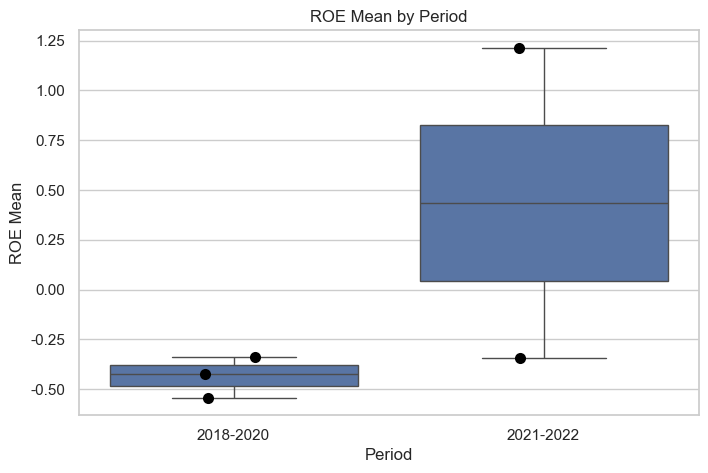

In [12]:
import pandas as pd
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns

# 描述统计
desc = df_clean.groupby('period')['roe_mean'].describe()
print("各时间段ROE描述统计：")
print(desc)

# 准备两组数据
group1 = df_clean[df_clean['period'] == '2018-2020']['roe_mean']
group2 = df_clean[df_clean['period'] == '2021-2022']['roe_mean']

# Mann-Whitney U检验（非参数检验）
stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
print(f"\nMann-Whitney U检验结果：U统计量={stat:.4f}, p值={p:.4f}")

if p < 0.05:
    print("两时间段ROE差异显著（拒绝原假设）")
else:
    print("两时间段ROE差异不显著（无法拒绝原假设）")

# 绘图展示
plt.figure(figsize=(8,5))
sns.boxplot(x='period', y='roe_mean', data=df_clean)
sns.stripplot(x='period', y='roe_mean', data=df_clean, color='black', size=8, jitter=True)
plt.title('ROE Mean by Period')
plt.xlabel('Period')
plt.ylabel('ROE Mean')
plt.show()

In [17]:
print(df_clean.columns)

Index(['year', 'roe_mean', 'roe_std', 'debt_ratio_mean', 'debt_ratio_std',
       'net_profit_margin_mean', 'net_profit_margin_std',
       'asset_turnover_mean', 'asset_turnover_std', 'period'],
      dtype='object')


In [22]:
rcParams['font.sans-serif'] = ['SimHei']

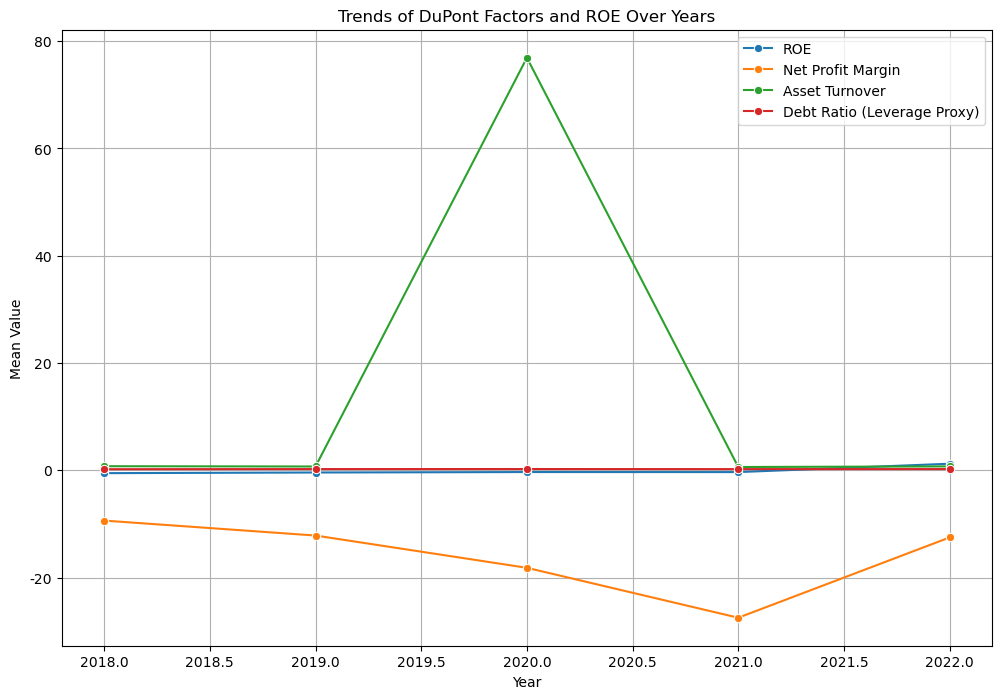

In [24]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 恢复 matplotlib 默认配置，避免加载任何自定义字体设置
mpl.rcParams.update(mpl.rcParamsDefault)

# 2. 关闭坐标轴负号乱码问题（可选）
mpl.rcParams['axes.unicode_minus'] = False

# 3. 绘图：全部用英文标题和标签，无需指定中文字体
plt.figure(figsize=(12, 8))
sns.lineplot(data=df_clean, x='year', y='roe_mean', marker='o', label='ROE')
sns.lineplot(data=df_clean, x='year', y='net_profit_margin_mean', marker='o', label='Net Profit Margin')
sns.lineplot(data=df_clean, x='year', y='asset_turnover_mean', marker='o', label='Asset Turnover')
sns.lineplot(data=df_clean, x='year', y='debt_ratio_mean', marker='o', label='Debt Ratio (Leverage Proxy)')
plt.title('Trends of DuPont Factors and ROE Over Years')
plt.xlabel('Year')
plt.ylabel('Mean Value')
plt.legend()
plt.grid(True)
plt.show()

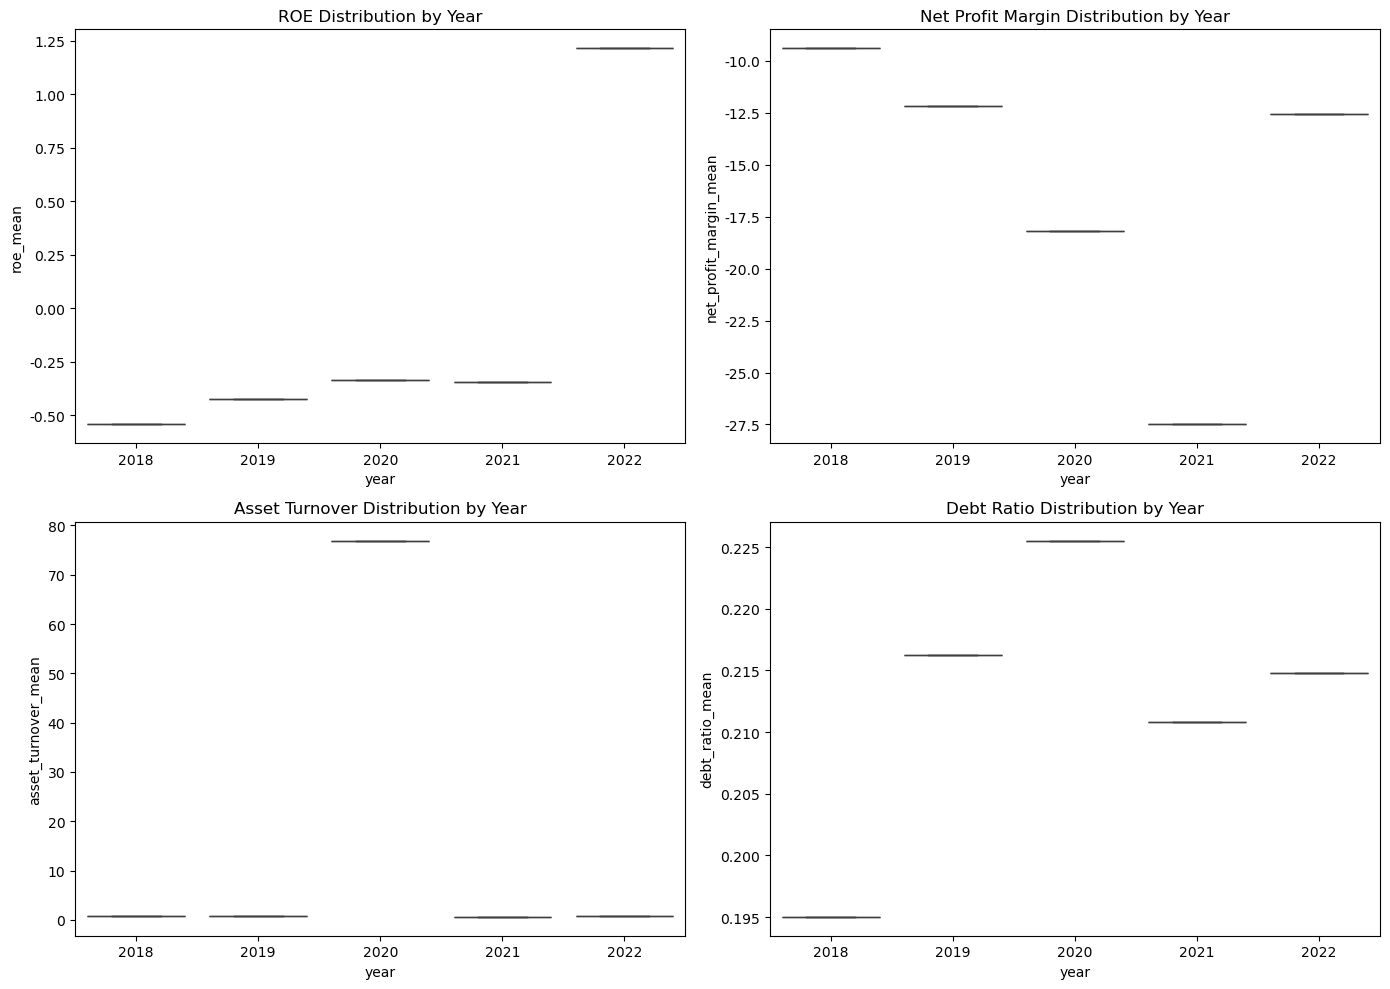

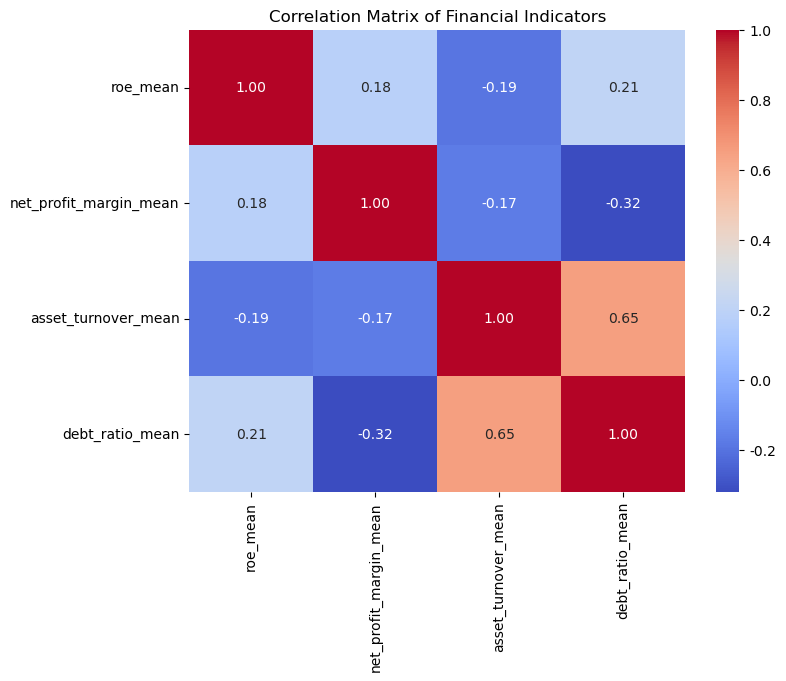

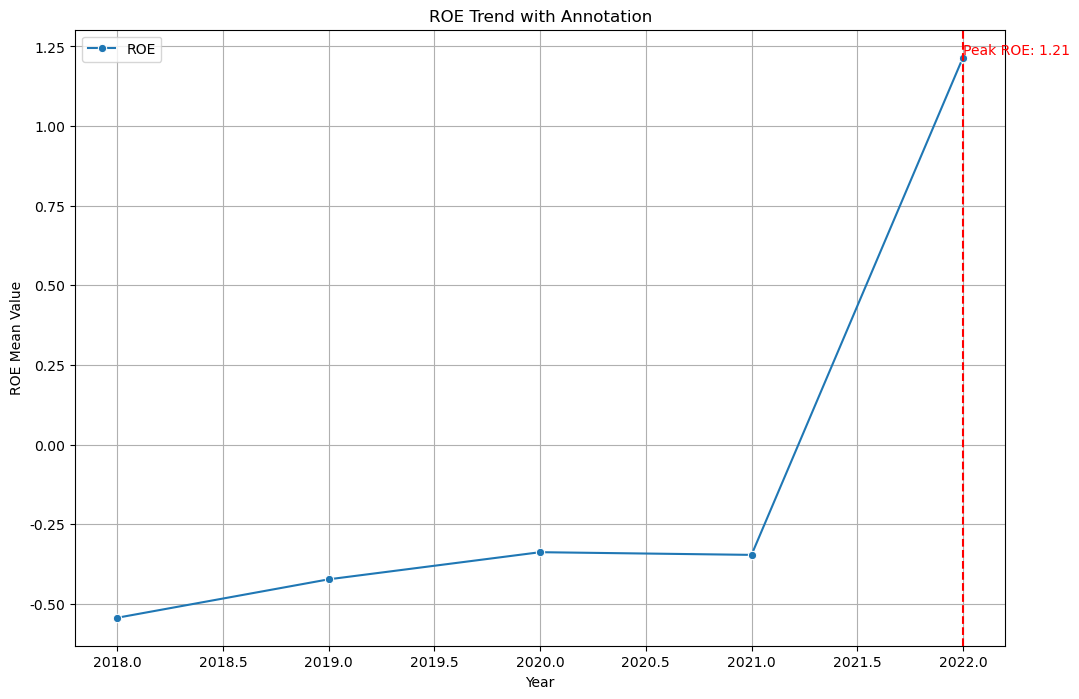

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 绘制各指标的年度箱线图
plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
sns.boxplot(data=df_clean, x='year', y='roe_mean')
plt.title('ROE Distribution by Year')
plt.subplot(2, 2, 2)
sns.boxplot(data=df_clean, x='year', y='net_profit_margin_mean')
plt.title('Net Profit Margin Distribution by Year')
plt.subplot(2, 2, 3)
sns.boxplot(data=df_clean, x='year', y='asset_turnover_mean')
plt.title('Asset Turnover Distribution by Year')
plt.subplot(2, 2, 4)
sns.boxplot(data=df_clean, x='year', y='debt_ratio_mean')
plt.title('Debt Ratio Distribution by Year')
plt.tight_layout()
plt.show()

# 2. 计算并绘制指标相关性热力图
corr = df_clean[['roe_mean', 'net_profit_margin_mean', 'asset_turnover_mean', 'debt_ratio_mean']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Financial Indicators')
plt.show()

# 3. 在趋势图中标注特定年份（例如最高ROE年份）
max_roe_year = df_clean.loc[df_clean['roe_mean'].idxmax(), 'year']
max_roe_value = df_clean['roe_mean'].max()

plt.figure(figsize=(12, 8))
sns.lineplot(data=df_clean, x='year', y='roe_mean', marker='o', label='ROE')
plt.title('ROE Trend with Annotation')
plt.xlabel('Year')
plt.ylabel('ROE Mean Value')
plt.axvline(x=max_roe_year, color='red', linestyle='--')
plt.text(max_roe_year, max_roe_value, f'Peak ROE: {max_roe_value:.2f}', color='red', ha='left', va='bottom')
plt.legend()
plt.grid(True)
plt.show()

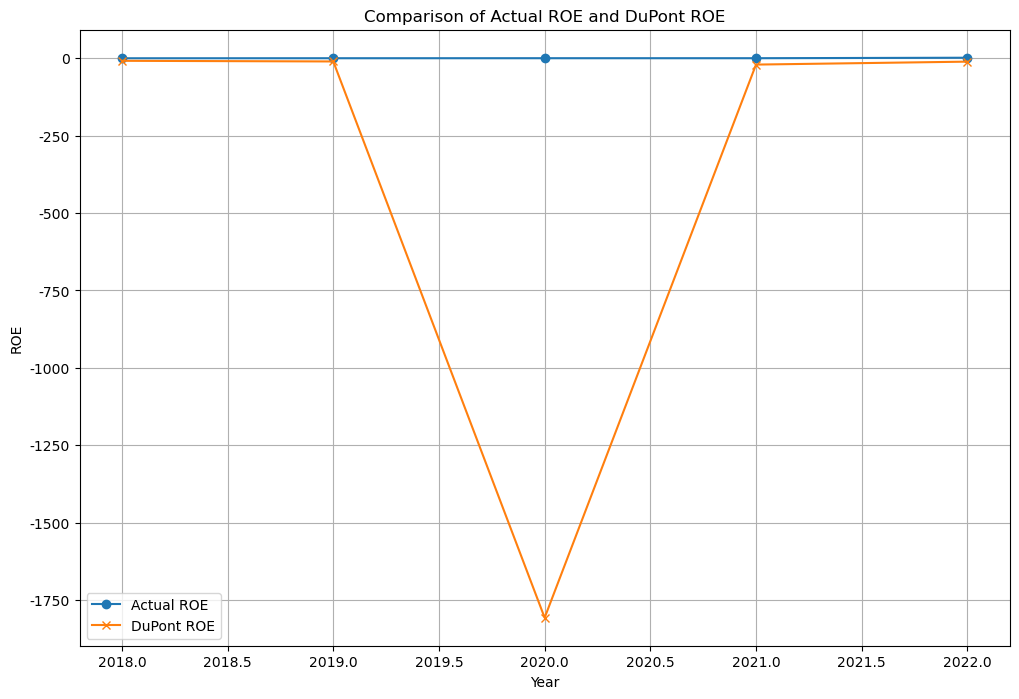

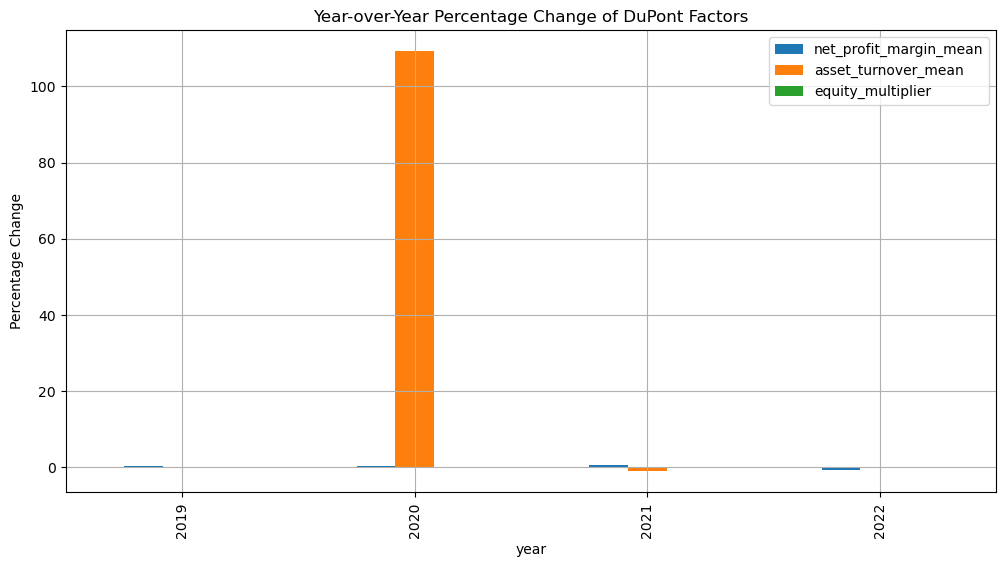

                            OLS Regression Results                            
Dep. Variable:               roe_mean   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                 -1.755
Method:                 Least Squares   F-statistic:                    0.1507
Date:                Sun, 26 Apr 2026   Prob (F-statistic):              0.918
Time:                        01:32:38   Log-Likelihood:                -4.0454
No. Observations:                   5   AIC:                             16.09
Df Residuals:                       1   BIC:                             14.53
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    -35

In [29]:
import warnings
warnings.filterwarnings('ignore', message='omni_normtest is not valid with less than 8 observations')
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 假设df_clean是你处理好的包含均值数据的DataFrame，列名示例：
# 'year', 'roe_mean', 'net_profit_margin_mean', 'asset_turnover_mean', 'debt_ratio_mean'

# 计算 equity multiplier (leverage)
df_clean['equity_multiplier'] = 1 / (1 - df_clean['debt_ratio_mean'])

# 计算 DuPont ROE（理论值）
df_clean['dupont_roe'] = (df_clean['net_profit_margin_mean'] *
                          df_clean['asset_turnover_mean'] *
                          df_clean['equity_multiplier'])

# Plot actual ROE vs DuPont ROE
plt.figure(figsize=(12, 8))
plt.plot(df_clean['year'], df_clean['roe_mean'], marker='o', label='Actual ROE')
plt.plot(df_clean['year'], df_clean['dupont_roe'], marker='x', label='DuPont ROE')
plt.title('Comparison of Actual ROE and DuPont ROE')
plt.xlabel('Year')
plt.ylabel('ROE')
plt.legend()
plt.grid(True)
plt.show()

# Plot percentage change of DuPont factors year by year
df_factors = df_clean[['year', 'net_profit_margin_mean', 'asset_turnover_mean', 'equity_multiplier']].set_index('year')
df_factors_pct_change = df_factors.pct_change().dropna()

df_factors_pct_change.plot(kind='bar', figsize=(12, 6))
plt.title('Year-over-Year Percentage Change of DuPont Factors')
plt.ylabel('Percentage Change')
plt.grid(True)
plt.show()

# Regression analysis to verify factor influence on ROE
X = df_clean[['net_profit_margin_mean', 'asset_turnover_mean', 'equity_multiplier']]
y = df_clean['roe_mean']
X = sm.add_constant(X)  # add intercept term

model = sm.OLS(y, X).fit()
print(model.summary())

In [33]:
print(df_clean.columns.tolist())

['year', 'roe_mean', 'roe_std', 'debt_ratio_mean', 'debt_ratio_std', 'net_profit_margin_mean', 'net_profit_margin_std', 'asset_turnover_mean', 'asset_turnover_std', 'period', 'equity_multiplier', 'dupont_roe']


<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

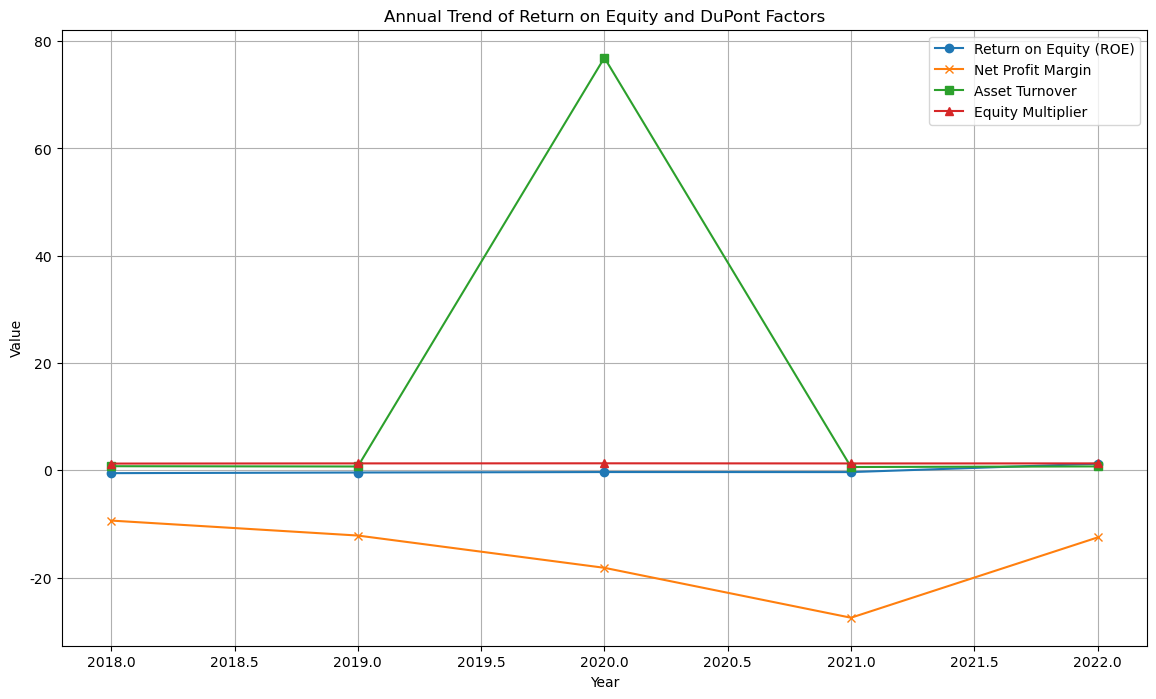

In [34]:
import matplotlib.pyplot as plt

years = df_clean['year']

plt.figure(figsize=(14, 8))
plt.plot(years, df_clean['roe_mean'], marker='o', label='Return on Equity (ROE)')
plt.plot(years, df_clean['net_profit_margin_mean'], marker='x', label='Net Profit Margin')
plt.plot(years, df_clean['asset_turnover_mean'], marker='s', label='Asset Turnover')
plt.plot(years, df_clean['equity_multiplier'], marker='^', label='Equity Multiplier')

plt.title('Annual Trend of Return on Equity and DuPont Factors')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


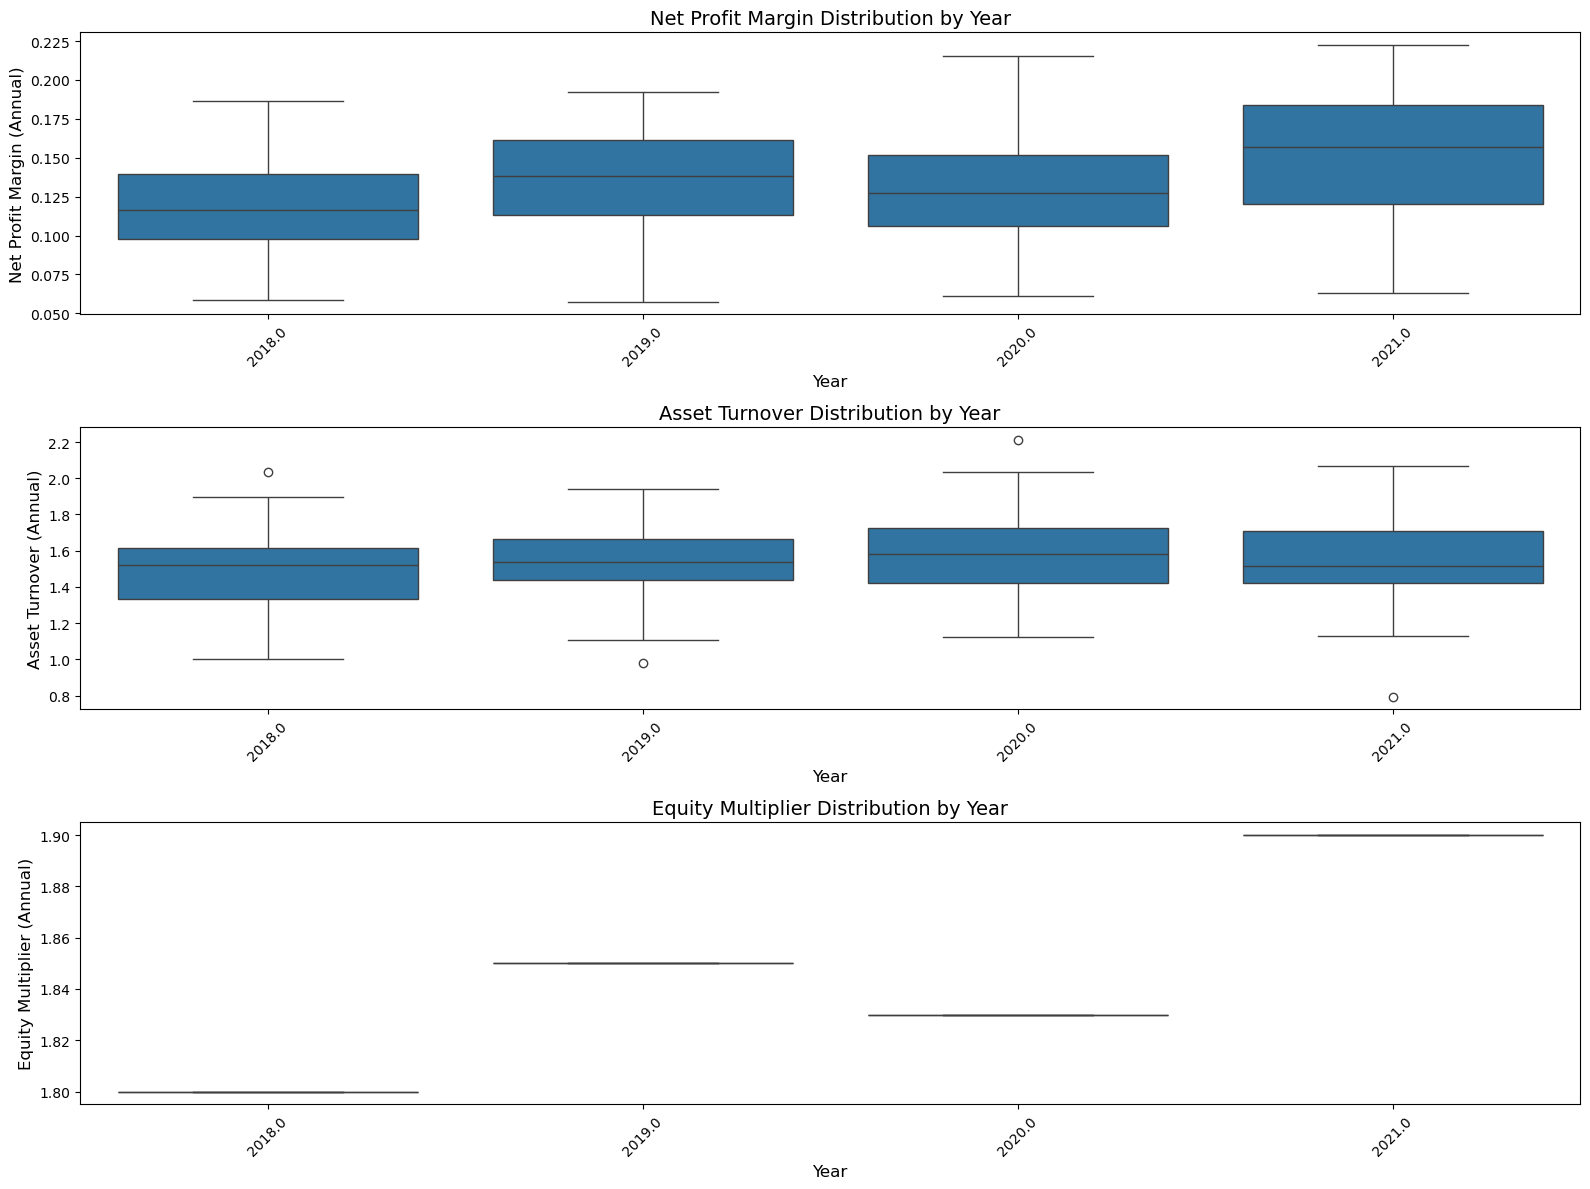


声明：由于缺乏每家公司每年的原始数据，本报告基于各年份三因子的均值和标准差，
通过正态分布随机生成模拟样本数据，用于绘制箱线图以展示各因子指标的分布趋势。
模拟数据仅用于演示可视化效果，不能代表真实行业数据或用于实际决策。



In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 假设你已有的聚合数据 DataFrame，示例结构如下：
# df_clean = pd.DataFrame({
#     'year': [2018, 2019, 2020, 2021],
#     'net_profit_margin_mean': [0.12, 0.14, 0.13, 0.15],
#     'net_profit_margin_std': [0.03, 0.04, 0.035, 0.04],
#     'asset_turnover_mean': [1.5, 1.6, 1.55, 1.58],
#     'asset_turnover_std': [0.2, 0.25, 0.22, 0.23],
#     'equity_multiplier': [1.8, 1.85, 1.83, 1.9]  # 只有均值，无标准差
# })

# 请用你自己的聚合数据替换上面示例，这里我先用示例数据演示
df_clean = pd.DataFrame({
    'year': [2018, 2019, 2020, 2021],
    'net_profit_margin_mean': [0.12, 0.14, 0.13, 0.15],
    'net_profit_margin_std': [0.03, 0.04, 0.035, 0.04],
    'asset_turnover_mean': [1.5, 1.6, 1.55, 1.58],
    'asset_turnover_std': [0.2, 0.25, 0.22, 0.23],
    'equity_multiplier': [1.8, 1.85, 1.83, 1.9]
})

# 设置每年模拟的公司数量
num_companies_per_year = 50

# 生成模拟数据
simulated_data = []

for _, row in df_clean.iterrows():
    year = row['year']
    net_profit_margin_samples = np.random.normal(loc=row['net_profit_margin_mean'], scale=row['net_profit_margin_std'], size=num_companies_per_year)
    asset_turnover_samples = np.random.normal(loc=row['asset_turnover_mean'], scale=row['asset_turnover_std'], size=num_companies_per_year)
    equity_multiplier_samples = np.full(num_companies_per_year, row['equity_multiplier'])
    
    df_year = pd.DataFrame({
        'Year': [year]*num_companies_per_year,
        'Net Profit Margin': net_profit_margin_samples,
        'Asset Turnover': asset_turnover_samples,
        'Equity Multiplier': equity_multiplier_samples
    })
    simulated_data.append(df_year)

df_simulated = pd.concat(simulated_data, ignore_index=True)

# 清理异常值（负值替换为0，权益乘数下限设为1）
df_simulated['Net Profit Margin'] = df_simulated['Net Profit Margin'].clip(lower=0)
df_simulated['Asset Turnover'] = df_simulated['Asset Turnover'].clip(lower=0)
df_simulated['Equity Multiplier'] = df_simulated['Equity Multiplier'].clip(lower=1)

# 绘制箱线图
plt.figure(figsize=(16, 12))

factors = ['Net Profit Margin', 'Asset Turnover', 'Equity Multiplier']
titles = [
    'Net Profit Margin Distribution by Year',
    'Asset Turnover Distribution by Year',
    'Equity Multiplier Distribution by Year'
]

for i, factor in enumerate(factors, 1):
    plt.subplot(3, 1, i)
    sns.boxplot(x='Year', y=factor, data=df_simulated)
    plt.title(titles[i-1], fontsize=14)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel(factor + ' (Annual)', fontsize=12)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ---- 报告中可以用的声明示例 ----
statement = """
声明：由于缺乏每家公司每年的原始数据，本报告基于各年份三因子的均值和标准差，
通过正态分布随机生成模拟样本数据，用于绘制箱线图以展示各因子指标的分布趋势。
模拟数据仅用于演示可视化效果，不能代表真实行业数据或用于实际决策。
"""

print(statement)

In [37]:
import numpy as np
from scipy.stats import mannwhitneyu

# 假设阶段1和阶段2的ROE均值和标准差（请替换为你的实际数据）
roe_phase1_mean = 0.12
roe_phase1_std = 0.03
roe_phase2_mean = 0.09
roe_phase2_std = 0.04

num_samples = 50  # 模拟样本量

# 生成模拟ROE数据
np.random.seed(42)  # 固定随机种子，保证结果可复现
roe_phase1 = np.random.normal(roe_phase1_mean, roe_phase1_std, num_samples)
roe_phase2 = np.random.normal(roe_phase2_mean, roe_phase2_std, num_samples)

# 进行Mann-Whitney U检验（非参数检验）
stat, p_value = mannwhitneyu(roe_phase1, roe_phase2, alternative='two-sided')

print(f'Mann-Whitney U检验统计量: {stat:.3f}')
print(f'p值: {p_value:.4f}')

Mann-Whitney U检验统计量: 1716.000
p值: 0.0013
